Pct change all · 

In [6]:
"""
Convert every numeric column (except Date) to day-over-day % change.
Simple, uniform transform if you want ALL columns on the same footing.
"""
import pandas as pd

IN_PATH = "/Users/surisettivamsikrishna/Downloads/Vamsi Pc/CODES/Qoin/Model data/master_aligned_fixed.csv"
OUT_PATH = "master_pct_change.csv"

# RSI columns are already bounded oscillators (0-100) - taking % change of them
# is meaningless and needlessly destroys rows (each scattered missing RSI value
# wipes out 2 rows once pct_change is applied). Keep these as raw levels.
NO_PCT_CHANGE_COLS = ["Nifty_RSI_14", "BankNifty_RSI_14", "ICICI_RSI_14"]

df = pd.read_csv(IN_PATH, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

out = pd.DataFrame({"Date": df["Date"]})
for col in df.columns:
    if col == "Date":
        continue
    if col in NO_PCT_CHANGE_COLS:
        out[col] = df[col]  # keep as raw level
    else:
        out[col] = df[col].pct_change() * 100  # in percent

out = out.dropna().reset_index(drop=True)
out.to_csv(OUT_PATH, index=False)
print(f"Wrote {OUT_PATH} with {len(out)} rows.")

Wrote master_pct_change.csv with 3999 rows.


In [ ]:
"""
Convert each column to the RIGHT transform based on its type:
  - Prices (ICICI, Nifty, BankNifty, Gold, USD_INR)      -> % change
  - Rates/yields (Repo, CRR, Bond_10Y/5Y, US_10Y/5Y)       -> simple difference (bps-like)
  - Flow values that can be negative/near-zero (FII, DII)  -> simple difference
  - Levels that are already bounded/indices (RSI, CPI, WPI,
    Trade_Balance, GDP growth, Net Profit, NII)             -> keep raw level
      (CPI/WPI/GDP are usually monthly-frequency forward-filled 
       taking pct_change on daily-ffilled data creates fake 0-then-spike noise,
       so we leave them as levels here. If you have a proper MoM/YoY series,
       swap that in instead.)

No dropna() on the full frame - each column's NaNs (leading NaN from pct_change/diff,
or genuine missing data) are left in place. This preserves row count; handle
NaNs per-column at analysis time (e.g. pairwise-complete correlation) instead
of wiping whole rows.
"""
import pandas as pd

IN_PATH = "/Users/surisettivamsikrishna/Downloads/Vamsi Pc/CODES/Qoin/Model data/master_aligned_fixed.csv"
OUT_PATH = "master_transformed.csv"

# Price-like columns -> % change
PCT_CHANGE_COLS = [
    "ICICI_Close", "Nifty_Close", "BankNifty_Close", "Gold_Close", "USD_INR",
]

# Rate/yield columns -> simple difference (NOT pct_change; a rate isn't a price)
DIFF_COLS = [
    "Bond_10Y", "Bond_5Y", "US_10Y", "US_5Y", "Repo_Rate_%", "CRR_%",
]

# Flow columns that can be negative/near-zero -> simple difference
FLOW_DIFF_COLS = [
    "FII_Net", "DII_Net",
]

# Already-level / bounded / low-frequency columns -> keep as-is
LEVEL_COLS = [
    "Nifty_RSI_14", "BankNifty_RSI_14", "ICICI_RSI_14",
    "CPI_Index", "WPI_Index", "Trade_Balance_Billion_USD",
    "Real_GDP_YoY_Growth_%", "Net Profit (₹ Cr)", "NII (₹ Cr)",
]

df = pd.read_csv(IN_PATH, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

out = pd.DataFrame({"Date": df["Date"]})

for col in df.columns:
    if col == "Date":
        continue

    if col in PCT_CHANGE_COLS:
        out[col] = df[col].pct_change() * 100          # % change

    elif col in DIFF_COLS:
        out[col] = df[col].diff()                       # simple difference

    elif col in FLOW_DIFF_COLS:
        out[col] = df[col].diff()                       # simple difference (avoids /0 blowups)

    elif col in LEVEL_COLS:
        out[col] = df[col]                               # raw level, untouched

    else:
        # Unrecognized column - default to raw level and flag it, rather than
        # silently guessing a transform that might be wrong.
        print(f"[warn] '{col}' not classified in any list - kept as raw level. "
              f"Check if it needs pct_change or diff instead.")
        out[col] = df[col]

# NOTE: no dropna() here on purpose.
# - pct_change()/diff() naturally produce NaN on row 0 for the transformed columns.
# - Any pre-existing missing data (e.g. monthly CPI ffilled with gaps) stays NaN too.
# Handle this at analysis time, e.g.:
#     out[["Gold_Close", "ICICI_Close"]].corr()   # pandas .corr() uses pairwise-complete by default
# rather than dropping entire rows here and losing unrelated columns' data.

out.to_csv(OUT_PATH, index=False)
print(f"Wrote {OUT_PATH} with {len(out)} rows (no rows dropped for NaNs).")
print(f"NaN count per column:\n{out.isna().sum()}")

Wrote master_transformed.csv with 4253 rows (no rows dropped for NaNs).
NaN count per column:
Date                           0
ICICI_Close                    1
Nifty_Close                    1
BankNifty_Close                1
Gold_Close                     1
USD_INR                        1
Bond_10Y                       1
Bond_5Y                        1
US_10Y                         1
US_5Y                          1
FII_Net                        1
DII_Net                        1
CPI_Index                      0
WPI_Index                      0
Trade_Balance_Billion_USD      0
Repo_Rate_%                    1
CRR_%                          1
Real_GDP_YoY_Growth_%          0
Net Profit (₹ Cr)              0
NII (₹ Cr)                     0
Nifty_RSI_14                 253
BankNifty_RSI_14             237
ICICI_RSI_14                 233
dtype: int64


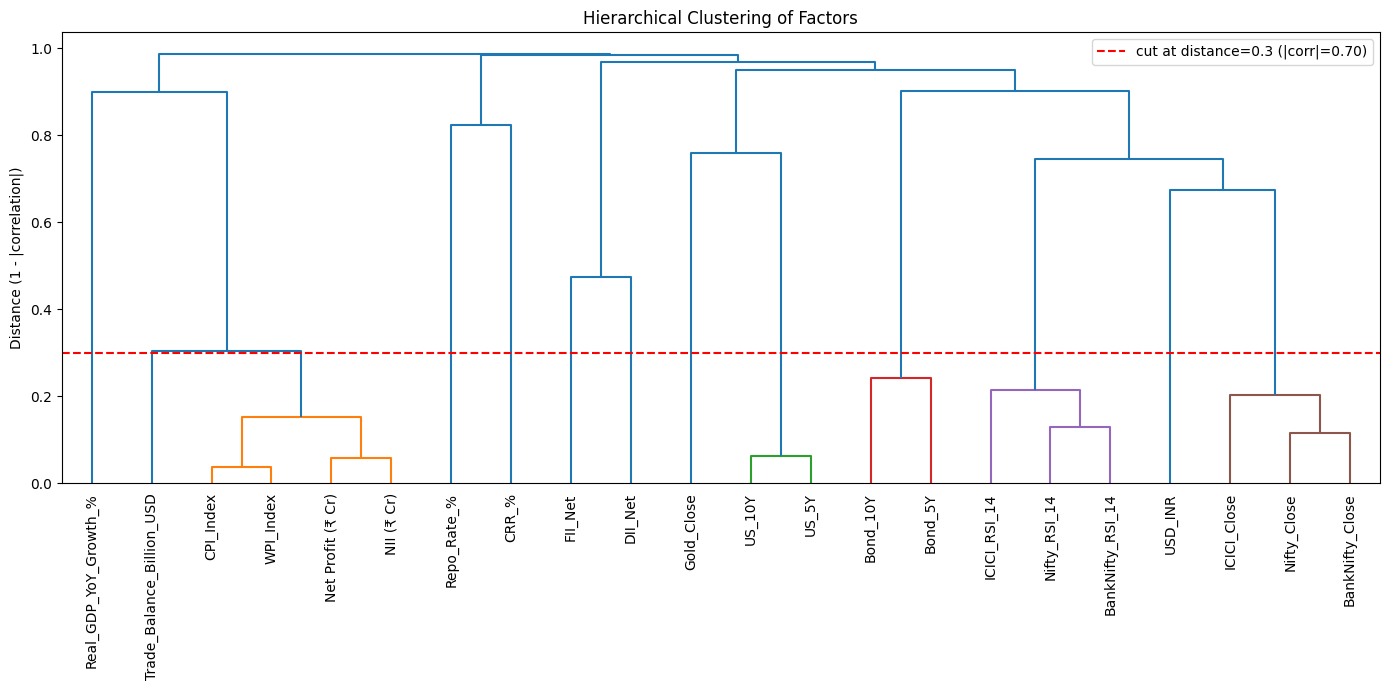


Cluster assignments:
                   Factor  Cluster
               NII (₹ Cr)        1
        Net Profit (₹ Cr)        1
                CPI_Index        1
                WPI_Index        1
Trade_Balance_Billion_USD        2
    Real_GDP_YoY_Growth_%        3
              Repo_Rate_%        4
                    CRR_%        5
                  FII_Net        6
                  DII_Net        7
                   US_10Y        8
                    US_5Y        8
               Gold_Close        9
                 Bond_10Y       10
                  Bond_5Y       10
             Nifty_RSI_14       11
             ICICI_RSI_14       11
         BankNifty_RSI_14       11
          BankNifty_Close       12
              Nifty_Close       12
              ICICI_Close       12
                  USD_INR       13

Grouped factors (candidates for PCA / picking one representative):
  Cluster 1: ['NII (₹ Cr)', 'Net Profit (₹ Cr)', 'CPI_Index', 'WPI_Index']  <-- cluster, consider PCA/one

In [8]:
"""
Pipeline: NxN correlation matrix -> distance (1 - |r|) -> hierarchical clustering
-> dendrogram -> cluster labels per factor.

Input: the transformed CSV from preprocess_factors.py (master_transformed.csv)
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

IN_PATH = "master_transformed.csv"          # output of preprocess_factors.py
DIST_THRESHOLD = 0.3                        # cut tree where distance = 0.3  -> |corr| = 0.7
                                             # lower this number = stricter (fewer, tighter clusters)

# ---------------------------------------------------------------
# 1. Load data, drop Date, keep only numeric factor columns
# ---------------------------------------------------------------
df = pd.read_csv(IN_PATH, parse_dates=["Date"])
factor_cols = [c for c in df.columns if c != "Date"]
data = df[factor_cols]

# ---------------------------------------------------------------
# 2. NxN correlation matrix (pairwise-complete, ignores NaNs per pair)
# ---------------------------------------------------------------
corr_matrix = data.corr(method="pearson")

# ---------------------------------------------------------------
# 3. Convert to distance: distance = 1 - |correlation|
#    High |corr| (near 1) -> small distance (near 0) -> merges early
#    Low |corr| (near 0)  -> large distance (near 1) -> stays separate
# ---------------------------------------------------------------
dist_matrix = 1 - corr_matrix.abs()

# Force exact 0 on the diagonal (floating point can leave tiny residues)
np.fill_diagonal(dist_matrix.values, 0)

# scipy linkage needs a condensed distance matrix (upper triangle, 1D)
condensed_dist = squareform(dist_matrix.values, checks=False)

# ---------------------------------------------------------------
# 4. Hierarchical clustering
#    method="average" (UPGMA) is a safe, commonly used default.
#    Other options: "single", "complete", "ward" (ward needs euclidean-like distances,
#    less appropriate here since our distance isn't strictly euclidean).
# ---------------------------------------------------------------
Z = linkage(condensed_dist, method="average")

# ---------------------------------------------------------------
# 5. Dendrogram
# ---------------------------------------------------------------
plt.figure(figsize=(14, 7))
dendrogram(
    Z,
    labels=factor_cols,
    leaf_rotation=90,
    color_threshold=DIST_THRESHOLD,
)
plt.axhline(y=DIST_THRESHOLD, color="red", linestyle="--",
            label=f"cut at distance={DIST_THRESHOLD} (|corr|={1-DIST_THRESHOLD:.2f})")
plt.ylabel("Distance (1 - |correlation|)")
plt.title("Hierarchical Clustering of Factors")
plt.legend()
plt.tight_layout()
plt.savefig("factor_dendrogram.png", dpi=150)
plt.show()

# ---------------------------------------------------------------
# 6. Cut the tree -> assign each factor to a cluster number
# ---------------------------------------------------------------
cluster_labels = fcluster(Z, t=DIST_THRESHOLD, criterion="distance")

cluster_df = pd.DataFrame({
    "Factor": factor_cols,
    "Cluster": cluster_labels,
}).sort_values("Cluster")

print("\nCluster assignments:")
print(cluster_df.to_string(index=False))

# ---------------------------------------------------------------
# 7. Show which factors ended up grouped together (the useful summary)
# ---------------------------------------------------------------
print("\nGrouped factors (candidates for PCA / picking one representative):")
for c in sorted(cluster_df["Cluster"].unique()):
    members = cluster_df.loc[cluster_df["Cluster"] == c, "Factor"].tolist()
    tag = "  <-- cluster, consider PCA/one representative" if len(members) > 1 else ""
    print(f"  Cluster {c}: {members}{tag}")

cluster_df.to_csv("factor_clusters.csv", index=False)
corr_matrix.to_csv("factor_correlation_matrix.csv")
print("\nSaved: factor_dendrogram.png, factor_clusters.csv, factor_correlation_matrix.csv")

/var/folders/10/4p6gdwfx3g74kjfj2_xqxz140000gn/T/ipykernel_9873/3890572557.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  factor_leads_sig.loc[col, f"t-{k}"] = (abs(r) > thresh) if not np.isnan(r) else False
/var/folders/10/4p6gdwfx3g74kjfj2_xqxz140000gn/T/ipykernel_9873/3890572557.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  factor_leads_sig.loc[col, f"t-{k}"] = (abs(r) > thresh) if not np.isnan(r) else False
/var/folders/10/4p6gdwfx3g74kjfj2_xqxz140000gn/T/ipykernel_9873/3890572557.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 

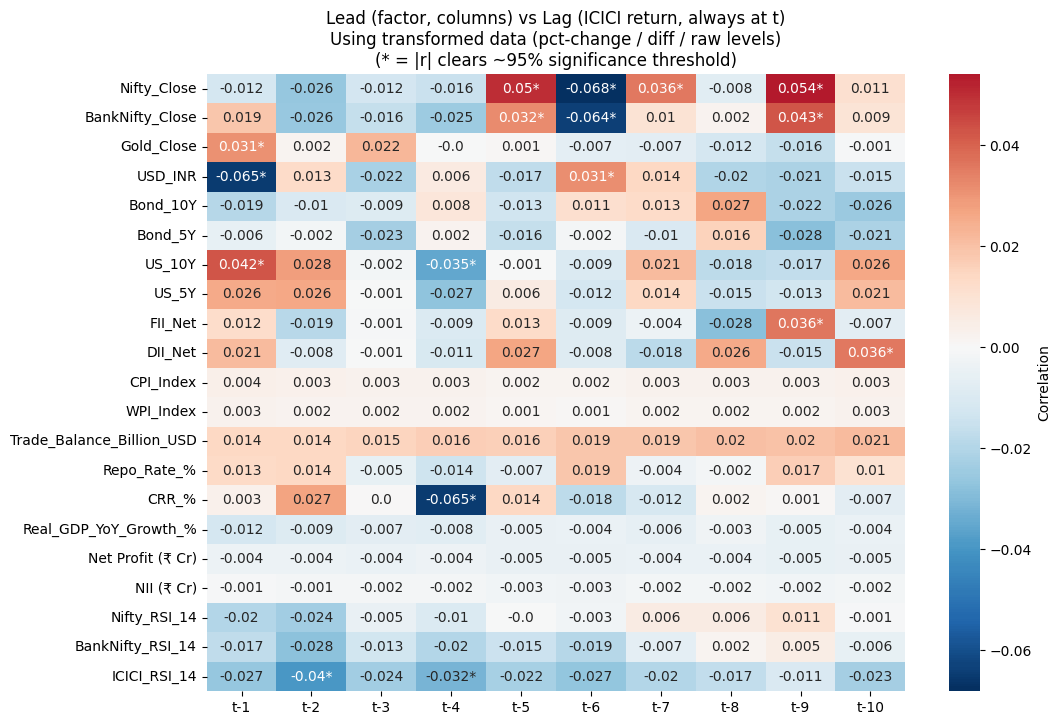

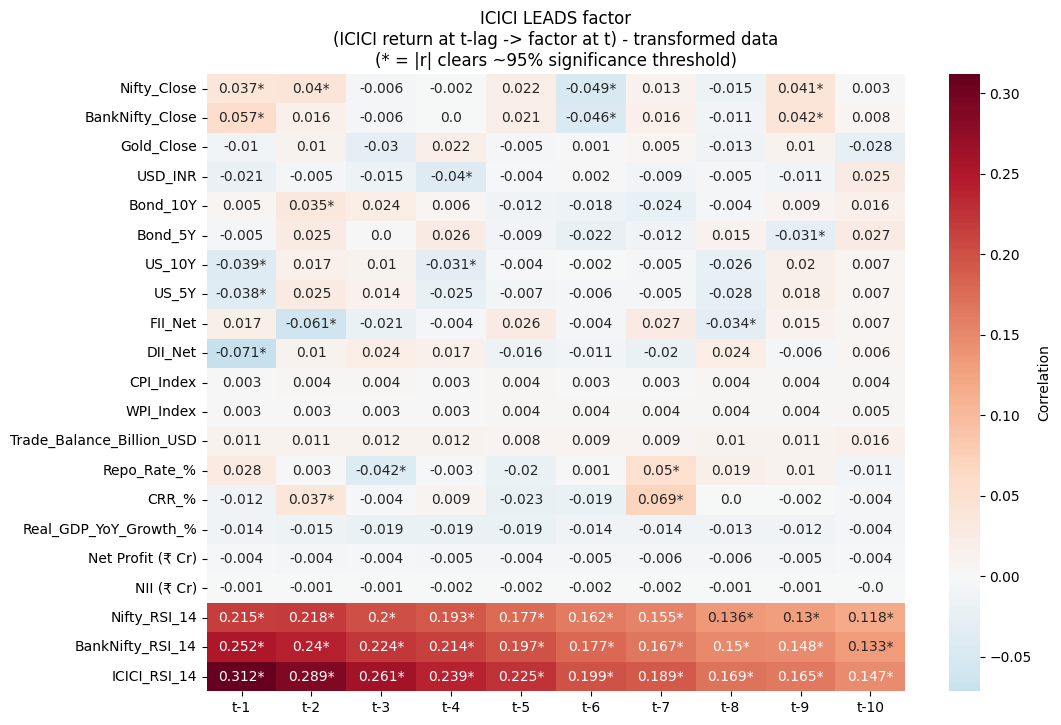

Saved: leadlag_factor_leads_transformed.png, leadlag_icici_leads_transformed.png
Cells marked with '*' are the only ones worth looking at - everything else is statistical noise.


In [9]:
"""
Lead-lag heatmaps using the PROPERLY TRANSFORMED data (master_transformed.csv)
instead of raw closing prices - fixes the earlier heatmaps which used raw
prices/levels and mixed non-stationary series with bounded oscillators.

Produces TWO heatmaps, same as before, but now on correct data:
  1. Factor leads ICICI:  Corr( Factor[t-k], ICICI_return[t] )  for k = 1..10
  2. ICICI leads Factor:  Corr( ICICI_return[t-k], Factor[t] )  for k = 1..10

Also overlays significance: cells where |r| clears the ~95% significance
threshold (2/sqrt(N)) are marked with '*' so noise doesn't get mistaken
for signal.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

IN_PATH = "master_transformed.csv"   # output of preprocess_factors.py
TARGET = "ICICI_Close"               # this column is now ICICI's % return (transformed)
MAX_LAG = 10

df = pd.read_csv(IN_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

factor_cols = [c for c in df.columns if c not in ("Date", TARGET)]

target_series = df[TARGET]

# ---------------------------------------------------------------
# Significance threshold: approx 95% CI for correlation under H0: r=0
# r_crit ~= 1.96 / sqrt(N - 3)   (Fisher z-approx); using simpler 2/sqrt(N) rule of thumb
# ---------------------------------------------------------------
def sig_threshold(n_obs):
    return 1.96 / np.sqrt(max(n_obs - 3, 1))

def corr_with_sig(x, y):
    """Pairwise-complete correlation + count of usable rows."""
    mask = x.notna() & y.notna()
    n = mask.sum()
    if n < 10:
        return np.nan, np.nan, n
    r = np.corrcoef(x[mask], y[mask])[0, 1]
    return r, sig_threshold(n), n

# ---------------------------------------------------------------
# 1. Factor LEADS ICICI: factor[t-k] vs ICICI_return[t]
# ---------------------------------------------------------------
factor_leads = pd.DataFrame(index=factor_cols, columns=[f"t-{k}" for k in range(1, MAX_LAG + 1)], dtype=float)
factor_leads_sig = factor_leads.copy()

for col in factor_cols:
    for k in range(1, MAX_LAG + 1):
        shifted_factor = df[col].shift(k)     # factor value k days BEFORE today
        r, thresh, n = corr_with_sig(shifted_factor, target_series)
        factor_leads.loc[col, f"t-{k}"] = r
        factor_leads_sig.loc[col, f"t-{k}"] = (abs(r) > thresh) if not np.isnan(r) else False

# ---------------------------------------------------------------
# 2. ICICI LEADS factor: ICICI_return[t-k] vs factor[t]
# ---------------------------------------------------------------
icici_leads = pd.DataFrame(index=factor_cols, columns=[f"t-{k}" for k in range(1, MAX_LAG + 1)], dtype=float)
icici_leads_sig = icici_leads.copy()

for col in factor_cols:
    for k in range(1, MAX_LAG + 1):
        shifted_icici = target_series.shift(k)   # ICICI return k days BEFORE today
        r, thresh, n = corr_with_sig(shifted_icici, df[col])
        icici_leads.loc[col, f"t-{k}"] = r
        icici_leads_sig.loc[col, f"t-{k}"] = (abs(r) > thresh) if not np.isnan(r) else False

# ---------------------------------------------------------------
# Plot helper: heatmap with '*' on significant cells
# ---------------------------------------------------------------
def plot_heatmap(matrix, sig_mask, title, fname):
    annot = matrix.round(3).astype(str)
    annot = annot + sig_mask.map(lambda x: "*" if x else "")

    plt.figure(figsize=(11, max(6, 0.35 * len(matrix))))
    sns.heatmap(
        matrix.astype(float),
        annot=annot,
        fmt="",
        cmap="RdBu_r",
        center=0,
        cbar_kws={"label": "Correlation"},
    )
    plt.title(title + "\n(* = |r| clears ~95% significance threshold)")
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.show()

plot_heatmap(
    factor_leads, factor_leads_sig,
    "Lead (factor, columns) vs Lag (ICICI return, always at t)\nUsing transformed data (pct-change / diff / raw levels)",
    "leadlag_factor_leads_transformed.png",
)

plot_heatmap(
    icici_leads, icici_leads_sig,
    "ICICI LEADS factor\n(ICICI return at t-lag -> factor at t) - transformed data",
    "leadlag_icici_leads_transformed.png",
)

factor_leads.to_csv("factor_leads_icici_corr.csv")
icici_leads.to_csv("icici_leads_factor_corr.csv")

print("Saved: leadlag_factor_leads_transformed.png, leadlag_icici_leads_transformed.png")
print("Cells marked with '*' are the only ones worth looking at - everything else is statistical noise.")

                           ICICI_Close  Nifty_Close  BankNifty_Close  \
ICICI_Close                       1.00         0.74             0.86   
Nifty_Close                       0.74         1.00             0.88   
BankNifty_Close                   0.86         0.88             1.00   
Gold_Close                        0.03         0.05             0.03   
USD_INR                          -0.28        -0.36            -0.34   
Bond_10Y                         -0.11        -0.11            -0.14   
Bond_5Y                          -0.15        -0.16            -0.18   
US_10Y                            0.08         0.11             0.09   
US_5Y                             0.06         0.09             0.07   
FII_Net                           0.08         0.10             0.10   
DII_Net                          -0.01        -0.04            -0.02   
CPI_Index                         0.00         0.00            -0.00   
WPI_Index                         0.00         0.00            -

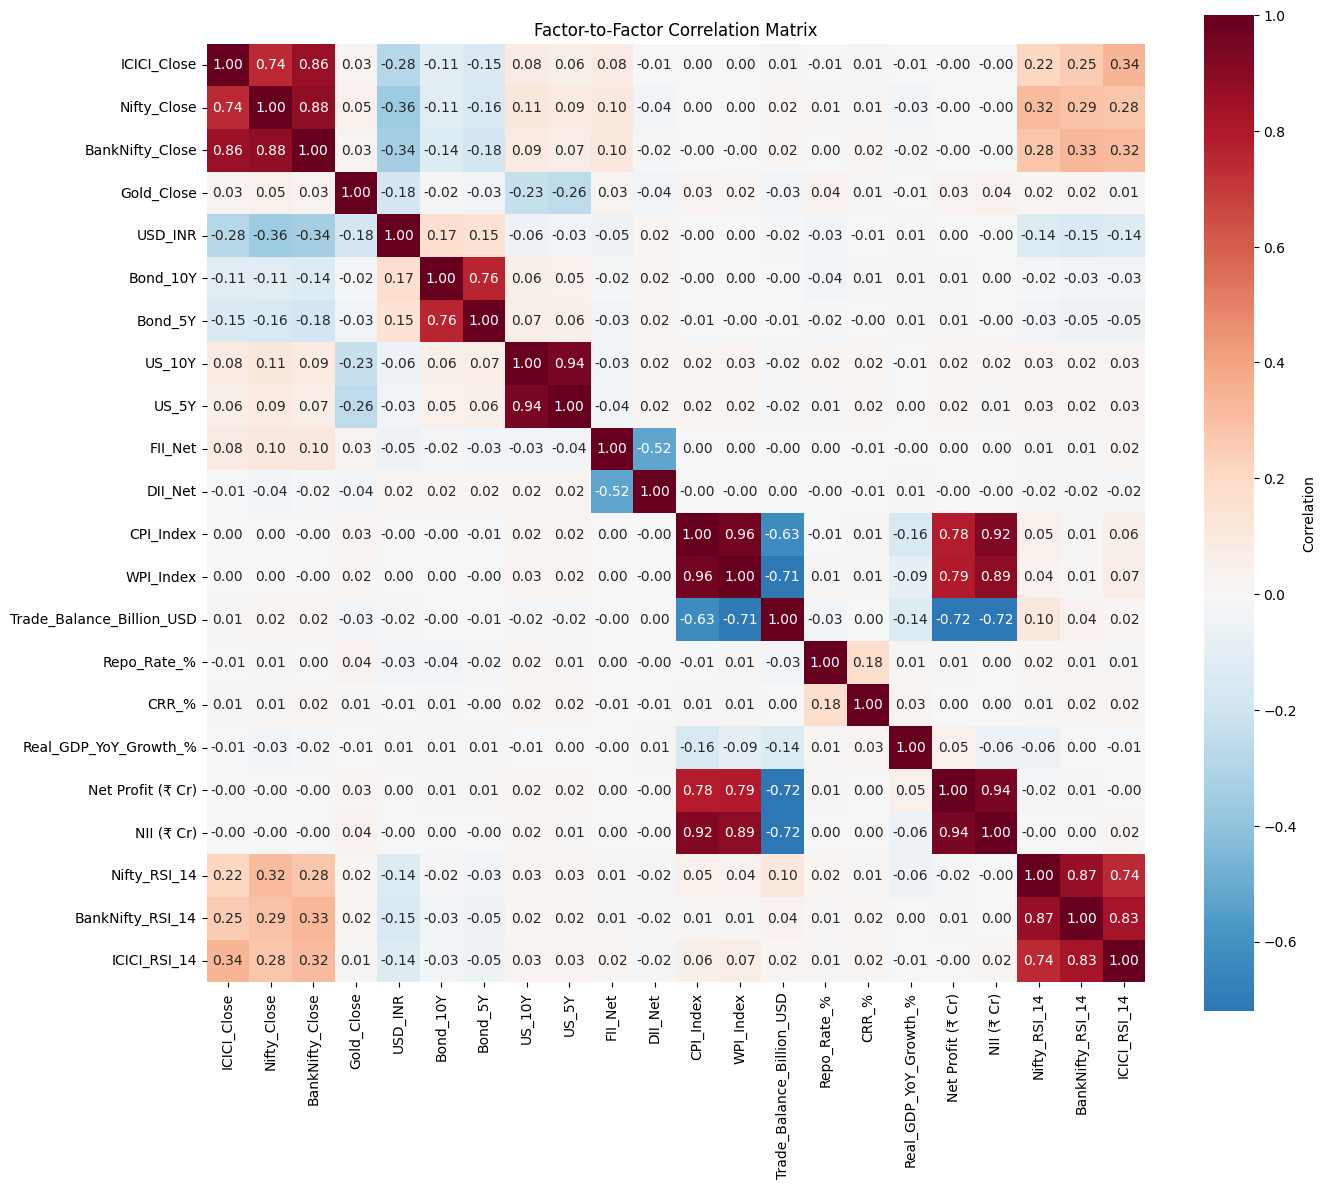

Saved: factor_correlation_matrix.csv, factor_correlation_matrix.png


In [10]:
"""
Build NxN correlation matrix from the transformed factor data.
"""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

IN_PATH = "/Users/surisettivamsikrishna/Downloads/Vamsi Pc/CODES/Qoin/PHASES/Phase2/master_transformed.csv"

df = pd.read_csv(IN_PATH, parse_dates=["Date"])
factor_cols = [c for c in df.columns if c != "Date"]

# Pairwise-complete correlation (NaNs handled per-pair, no row dropping)
corr_matrix = df[factor_cols].corr(method="pearson").round(2)

corr_matrix.to_csv("factor_correlation_matrix.csv")
print(corr_matrix)

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"label": "Correlation"},
)
plt.title("Factor-to-Factor Correlation Matrix")
plt.tight_layout()
plt.savefig("factor_correlation_matrix.png", dpi=150)
plt.show()

print("Saved: factor_correlation_matrix.csv, factor_correlation_matrix.png")